# Product Recommendation
A recommender system that will find similar looking products

## Step 1 - Load Data

Download the raw image dataset into a directory. Categorize these images into their respective category directories. Make sure that images are of the same type, JPEG recommended. We will also process the metadata and store it in a serialized file, CSV recommended.

* Download from https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
* Extract images to folder DataSet
* Create folder DataSet/Fashion_data

In [ ]:
import pandas as pd
from shutil import move
import os
from tqdm import tqdm

if not os.path.exists('Dataset/Fashion_data'):
    os.mkdir('Dataset/Fashion_data')
    os.chdir('Dataset/Fashion_data')

# read csv with map each image id to a category
df = pd.read_csv('Dataset/styles.csv', usecols=['id','masterCategory']).reset_index()
df['id'] = df['id'].astype('str')

# Initially images are on folder Dataset/images/ 
all_images = os.listdir('Dataset/images/')
co = 0

#iterate images moving then to one folder specific for each category
os.mkdir('Dataset/Fashion_data/categories')
for image in tqdm(all_images):
    category = df[df['id'] == image.split('.')[0]]['masterCategory']
    category = str(list(category)[0])
    if not os.path.exists(os.path.join('Dataset/Fashion_data/categories', category)):
        os.mkdir(os.path.join('Dataset/Fashion_data/categories', category))
    path_from = os.path.join('Dataset/images', image)
    path_to = os.path.join('Dataset/Fashion_data/categories', category, image)
    move(path_from, path_to)
    co += 1
print('Moved {} images.'.format(co))

100%|██████████| 42797/42797 [02:36<00:00, 273.85it/s]

Moved 42797 images.


### Step 2: Encoder Fine-tuning [optional]
Download the pre-trained image model and add two additional layers on top of that: the first layer is a feature vector layer and the second layer is the classification layer. We will only train these 2 layers on our data and after training, we will select the feature vector layer as the output of our fine-tuned encoder. After fine-tuning the model, we will save the feature extractor for later use.

In [183]:
import itertools
import os
import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

# pip install tensorflow_hub --only-binary tensorflow_hub
#import tensorflow_hub as hub
#print("Hub version:", hub.__version__)

TF version: 2.20.0
GPU is NOT AVAILABLE


In [ ]:
IMAGE_SIZE = (224, 224)
#MODULE_HANDLE = 'https://tfhub.dev/google/bit/m-r50x3/1'
#print("Using {} with input size {}".format(MODULE_HANDLE, IMAGE_SIZE))
print("Using VGG16 with input size {}".format( IMAGE_SIZE))
BATCH_SIZE = 32
N_FEATURES = 256

#hide
data_dir = 'Dataset/Fashion_data/categories'

Using VGG16 with input size (224, 224)


In [27]:
datagen_kwargs = dict(rescale=1./255, validation_split=.20)
dataflow_kwargs = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                   interpolation="bilinear")

valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    **datagen_kwargs)
valid_generator = valid_datagen.flow_from_directory(
    data_dir, subset="validation", shuffle=False, **dataflow_kwargs)

do_data_augmentation = False
if do_data_augmentation:
  train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
      rotation_range=40,
      horizontal_flip=True,
      width_shift_range=0.2, height_shift_range=0.2,
      shear_range=0.2, zoom_range=0.2,
      **datagen_kwargs)
else:
  train_datagen = valid_datagen
train_generator = train_datagen.flow_from_directory(
    data_dir, subset="training", shuffle=True, **dataflow_kwargs)

Found 8557 images belonging to 7 classes.
Found 34240 images belonging to 7 classes.


## Step 3 -Define Model

In [31]:
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=True)
for layer in base_model.layers:
    layer.trainable = False

In [33]:
print("Building model with VGG16")

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=IMAGE_SIZE + (3,)),
    #hub.KerasLayer(MODULE_HANDLE, trainable=False),
    base_model,
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(N_FEATURES,
                          kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(train_generator.num_classes,
                          kernel_regularizer=tf.keras.regularizers.l2(0.0001))
])
model.build((None,)+IMAGE_SIZE+(3,))
model.summary()

Building model with VGG16


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1000)           │   138,357,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,615,599 (528.78 MB)

 Trainable params: 258,055 (1008.03 KB)

 Non-trainable params: 138,357,544 (527.79 MB)

In [34]:
# Define optimiser and loss
lr = 0.003 * BATCH_SIZE / 512
SCHEDULE_LENGTH = 500
SCHEDULE_BOUNDARIES = [200, 300, 400]

# Decay learning rate by a factor of 10 at SCHEDULE_BOUNDARIES.
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=SCHEDULE_BOUNDARIES,
                                                                   values=[lr, lr*0.1, lr*0.001, lr*0.0001])
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)

loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

## Step 4 - Train Model

In [35]:
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = valid_generator.samples // valid_generator.batch_size
hist = model.fit(
    train_generator,
    epochs=5, steps_per_epoch=steps_per_epoch,
    validation_data=valid_generator,
    validation_steps=validation_steps).history

Epoch 1/5
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2715s 3s/step - accuracy: 0.4729 - loss: 1.8177 - val_accuracy: 0.4768 - val_loss: 1.7976
Epoch 2/5
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2710s 3s/step - accuracy: 0.4759 - loss: 1.7981 - val_accuracy: 0.4768 - val_loss: 1.7976
Epoch 3/5
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2755s 3s/step - accuracy: 0.4759 - loss: 1.7981 - val_accuracy: 0.4768 - val_loss: 1.7975
Epoch 4/5
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2771s 3s/step - accuracy: 0.4759 - loss: 1.7980 - val_accuracy: 0.4768 - val_loss: 1.7974
Epoch 5/5
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2790s 3s/step - accuracy: 0.4759 - loss: 1.7979 - val_accuracy: 0.4768 - val_loss: 1.7973


In [36]:
model.save("product_recomendation_model.keras")

## Step 5 - Evaluate accuracy / loss

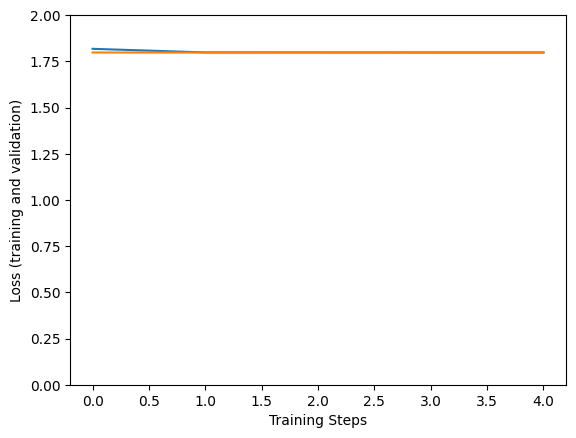

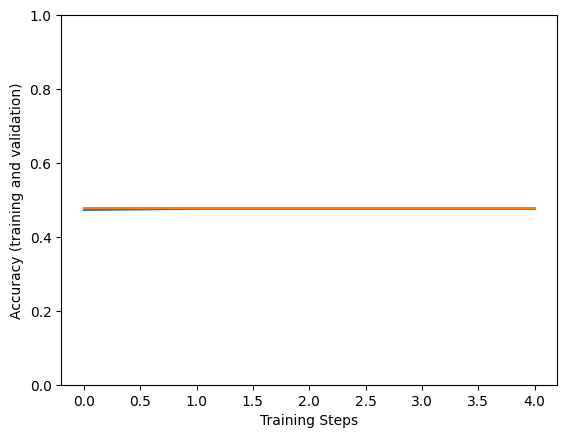

In [37]:
#hide
plt.figure()
plt.ylabel("Loss (training and validation)")
plt.xlabel("Training Steps")
plt.ylim([0,2])
plt.plot(hist["loss"])
plt.plot(hist["val_loss"])

plt.figure()
plt.ylabel("Accuracy (training and validation)")
plt.xlabel("Training Steps")
plt.ylim([0,1])
plt.plot(hist["accuracy"])
plt.plot(hist["val_accuracy"])

In [ ]:
if not os.path.exists('Dataset/ImgSim'):
    os.mkdir('Dataset/ImgSim')

# SAVE model
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-3].output)
feature_extractor.save('Dataset/ImgSim/bit_feature_extractor.keras')

### Step 6 - Image Vectorization
Now, we will use the encoder (prepared in step 2) to encode the images (prepared in step 1). We will save feature vector of each image as an array in a directory. After processing, we will save these embeddings for later use.

In [85]:
#hide
import tensorflow as tf
from pathlib import Path
import numpy as np
import os
from tqdm import tqdm
tqdm.pandas()

In [93]:
img_paths = []
for path in Path('Dataset/Fashion_data/categories').rglob('*.jpg'):
  img_paths.append(path)
np.random.shuffle(img_paths)

In [94]:
def load_img(path):
  img = tf.io.read_file(path)
  img = tf.io.decode_jpeg(img, channels=3)
  img = tf.image.resize_with_pad(img, 224, 224)
  img  = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]
  return img

In [95]:
# LOAD model
module = tf.keras.models.load_model('Dataset/ImgSim/bit_feature_extractor.keras')

In [ ]:
imgvec_path = 'Dataset/img_vectors/'
Path(imgvec_path).mkdir(parents=True, exist_ok=True)

In [97]:
for filename in tqdm(img_paths[:5000]):
    img = load_img(str(filename))
    features = module(img)
    feature_set = np.squeeze(features)
    outfile_name = os.path.basename(filename).split('.')[0] + ".npz"
    out_path_file = os.path.join(imgvec_path, outfile_name)
    np.savetxt(out_path_file, feature_set, delimiter=',')

100%|██████████| 5000/5000 [21:21<00:00,  3.90it/s]


## Step 7 - Metadata and Indexing
We will assign a unique id to each image and create dictionaries to locate information of this image: 1) Image id to Image name dictionary, 2) Image id to image feature vector dictionary, and 3) (optional) Image id to metadata product id dictionary. We will also create an image id to image feature vector indexing. Then we will save these dictionaries and index object for later use.

In [114]:
#hide
import pandas as pd
import glob
import os
import numpy as np
from tqdm import tqdm
tqdm.pandas()
#!pip install -q annoy
import json
from annoy import AnnoyIndex
from scipy import spatial
import pickle
from IPython.display import Image as dispImage

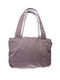

In [115]:
test_img = 'Dataset/Fashion_data/categories/Accessories/1941.jpg'
dispImage(test_img)

In [184]:
root_path = 'Dataset/ImgSim'
styles = pd.read_csv('Dataset/styles.csv', on_bad_lines='skip')
styles['id'] = styles['id'].astype('str')
styles.to_csv(root_path+'/styles.csv', index=False)

In [117]:
def match_id(fname):
  return styles.index[styles.id==fname].values[0]

In [118]:
# Defining data structures as empty dict
file_index_to_file_name = {}
file_index_to_file_vector = {}
file_index_to_product_id = {}

# Configuring annoy parameters
dims = 256
n_nearest_neighbors = 20
trees = 10000

# Reads all file names which stores feature vectors
allfiles = glob.glob('Dataset/img_vectors/*.npz')

t = AnnoyIndex(dims, metric='angular')

In [119]:
for findex, fname in tqdm(enumerate(allfiles)):
  file_vector = np.loadtxt(fname)
  file_name = os.path.basename(fname).split('.')[0]
  file_index_to_file_name[findex] = file_name
  file_index_to_file_vector[findex] = file_vector
  try:
    file_index_to_product_id[findex] = match_id(file_name)
  except IndexError:
    pass
  t.add_item(findex, file_vector)

5000it [01:49, 45.50it/s]


In [ ]:
t.build(trees)
t.save('t.ann')

True

In [122]:
file_path = 'Dataset/ImgSim/'
t.save(file_path+'indexer.ann')
pickle.dump(file_index_to_file_name, open(file_path+"file_index_to_file_name.p", "wb"))
pickle.dump(file_index_to_file_vector, open(file_path+"file_index_to_file_vector.p", "wb"))
pickle.dump(file_index_to_product_id, open(file_path+"file_index_to_product_id.p", "wb"))

## Step 8 - Local Testing
We will load a random image and find top-K most similar images.

In [ ]:
from PIL import Image
import matplotlib.image as mpimg
import requests

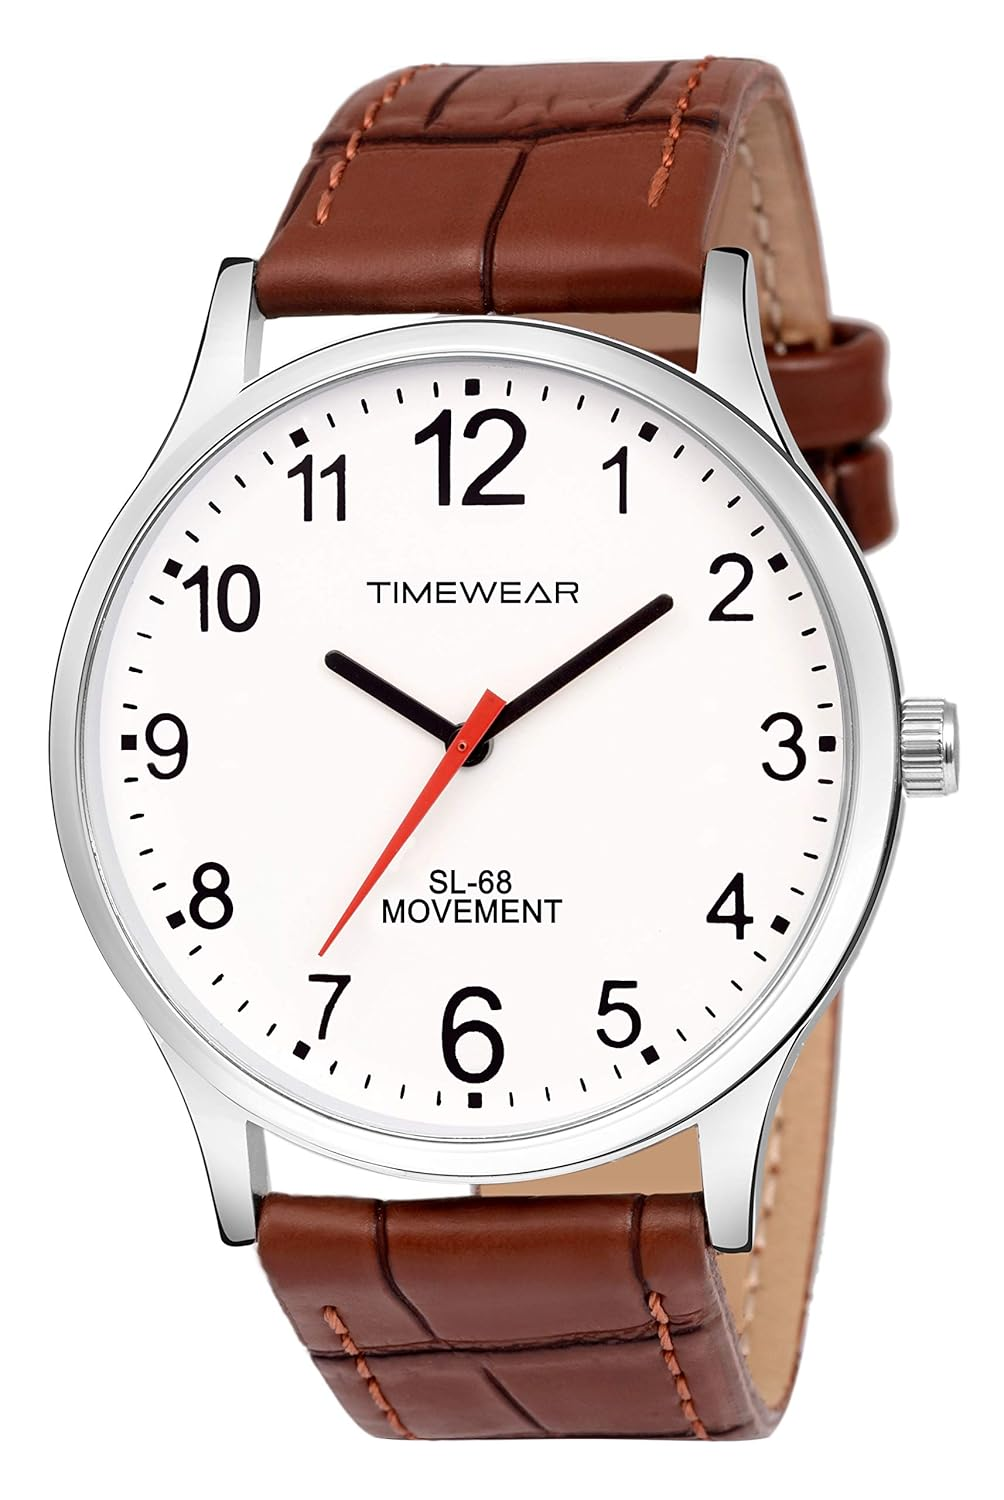

In [ ]:
# Load a watch image
img_addr = 'https://images-na.ssl-images-amazon.com/images/I/81%2Bd6eSA0eL._UL1500_.jpg'
test_img = Image.open(requests.get(img_addr, stream=True).raw)
test_img

In [182]:
image_url = tf.keras.utils.get_file('Watch', origin=img_addr )
image = tf.keras.utils.load_img(image_url,target_size = (224, 224))
input_arr = tf.keras.utils.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
test_vec = np.squeeze(module(input_arr))

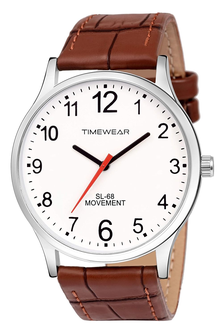

In [178]:
topK = 4 #Find top k similar images
basewidth = 224
img = Image.open(requests.get(img_addr, stream=True).raw)
wpercent = (basewidth/float(img.size[0]))
hsize = int((float(img.size[1])*float(wpercent)))
img = img.resize((basewidth,hsize), Image.Resampling.LANCZOS)
img

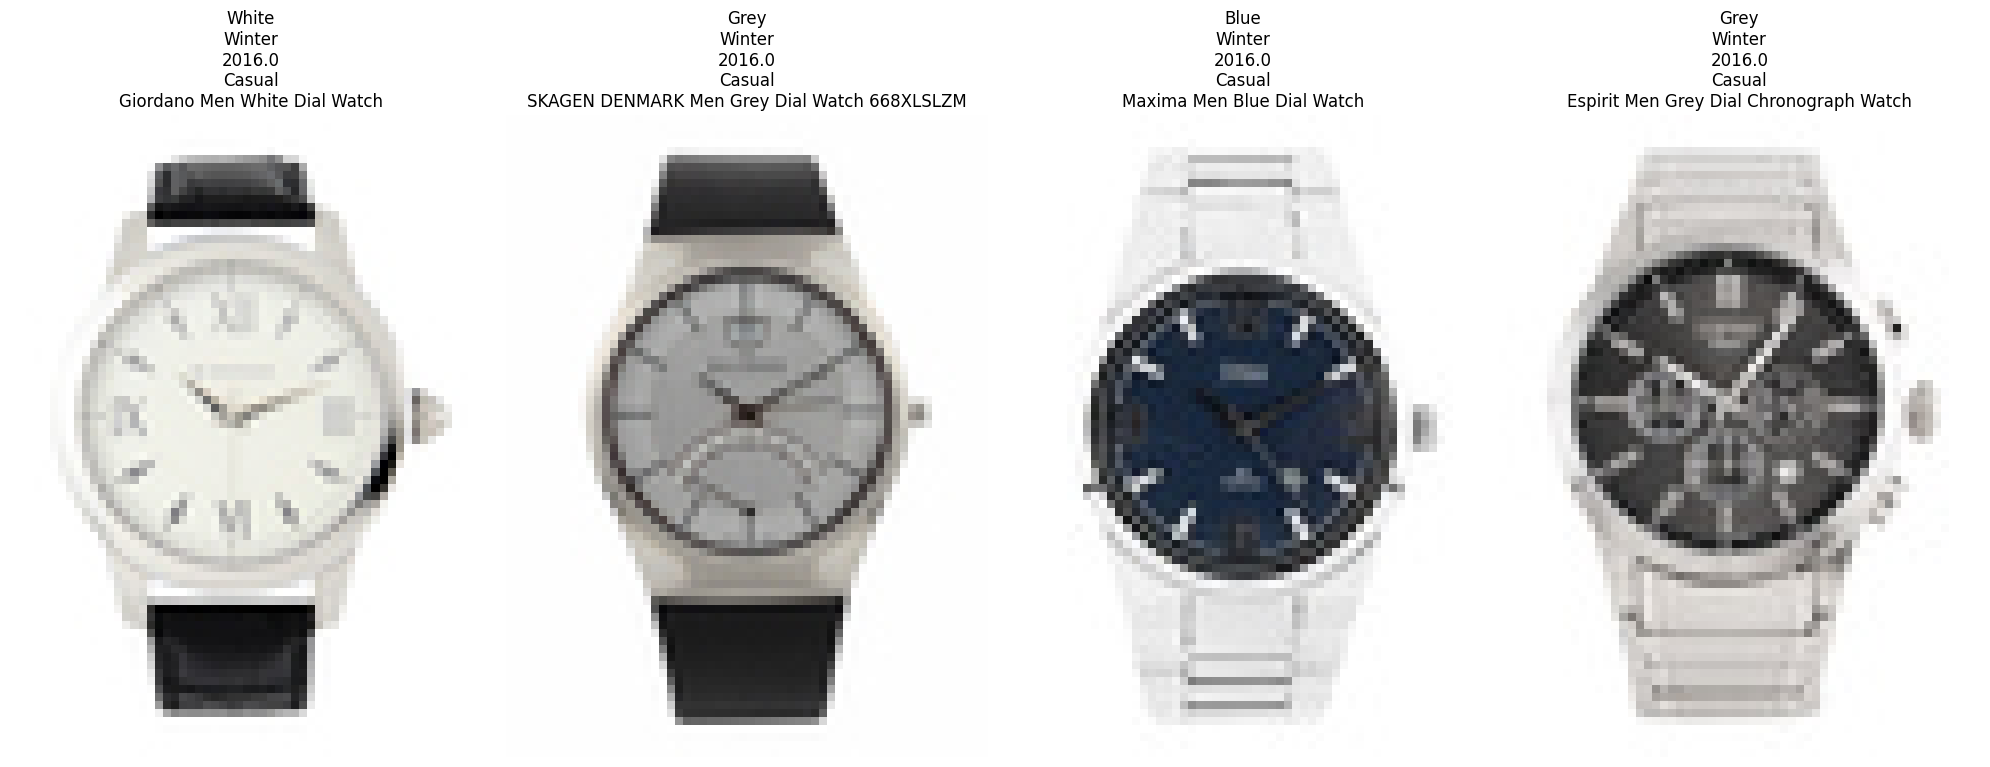

In [ ]:
#Find similar images
path_dict = {}
for path in Path('Dataset/Fashion_data/categories').rglob('*.jpg'):
  path_dict[path.name] = path

nns = t.get_nns_by_vector(test_vec, n=topK)
plt.figure(figsize=(20, 10))
for i in range(topK):
  x = file_index_to_file_name[nns[i]]
  x = path_dict[x+'.jpg']
  y = file_index_to_product_id[nns[i]]
  title = '\n'.join([str(j) for j in list(styles.loc[y].values[-5:])])
  plt.subplot(1, topK, i+1)
  plt.title(title)
  plt.imshow(mpimg.imread(x))
  plt.axis('off')
plt.tight_layout()